In [1]:
# Importo le librerie necessarie per costruire una NN per prevedere la SOC
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

from keras.callbacks import EarlyStopping

# Carico il dataset DS_Modelli
DS_Modelli = pd.read_csv(r"C:\Users\Bisite\Downloads\Progetti-main\Progetti-main\DS_Modelli.csv", index_col=0)
print(DS_Modelli.head())

              DateTime        Pv    Pv-Bat  Pv-#  Bat-Load  #-Load  \
0  2023-09-18 00:00:00  1.807064  0.037139   0.0  0.000000     0.0   
1  2023-09-18 01:00:00  1.360586  0.000000   0.0  0.544158     0.0   
2  2023-09-18 02:00:00  1.739977  0.000000   0.0  0.201029     0.0   
3  2023-09-18 03:00:00  2.011962  0.166737   0.0  0.000000     0.0   
4  2023-09-18 04:00:00  2.115072  0.285270   0.0  0.000000     0.0   

   Total_Load         Et       SOC  
0    1.769925  40.035282  0.500441  
1    1.904744  39.462484  0.493281  
2    1.941006  39.250875  0.490636  
3    1.845225  39.409274  0.492616  
4    1.829802  39.680281  0.496004  


In [2]:
# Definisco le colonne target
target_cols = [ 'Pv-#', 'Pv-Bat' ,'Bat-Load','#-Load','Et']

# Creo delle colonne aggiuntive di shift (-1) temporali per le colonne target
for col in target_cols:
    #DS_Modelli[col + '_prev1'] = DS_Modelli[col].shift(1)
    DS_Modelli[col + '_prev3'] = DS_Modelli[col].shift(3)
    DS_Modelli[col + '_prev6'] = DS_Modelli[col].shift(6)
    DS_Modelli[col + '_prev12'] = DS_Modelli[col].shift(12)
    DS_Modelli[col + '_prev24'] = DS_Modelli[col].shift(24)
DS_Modelli['Et_shift(-1)'] = DS_Modelli['Et'].shift(1)

# Elimino le righe con valori mancanti
DS_Modelli = DS_Modelli.dropna()

# Aggiungo delle colonne di suplus e deficit per prevedere meglio il flusso Pv-#
DS_Modelli['Net'] = DS_Modelli['Pv'] - DS_Modelli['Total_Load']
#DS_Modelli['Pv-#_Act'] = (DS_Modelli['Pv'] > 0).astype(int)

DS_Modelli['Net+Et(-1)'] = DS_Modelli['Et_shift(-1)'] + DS_Modelli['Net']
DS_Modelli['80-Et(-1)'] = 80 - DS_Modelli['Et_shift(-1)']


# Definisco le colonne input
feature_cols = ['Pv', 'Total_Load', 
                'Year', 'Month', 'Day', 'Hour',
                'Pv-#_prev12', 'Pv-#_prev3', 'Pv-#_prev6', 'Pv-#_prev24',
                'Pv-Bat_prev12', 'Pv-Bat_prev3', 'Pv-Bat_prev6', 'Pv-Bat_prev24',
                'Bat-Load_prev12', 'Bat-Load_prev3', 'Bat-Load_prev6', 'Bat-Load_prev24',
                '#-Load_prev12', '#-Load_prev3', '#-Load_prev6', '#-Load_prev24',
                'Et_prev12', 'Et_prev3', 'Et_prev6', 'Et_prev24',
                'Net', 
                #'Pv-#_Act',
                #'Et_shift(-1)','Net+Et(-1)'
                ]

In [3]:
df = DS_Modelli.copy()

# Transformo la colonna 'DateTime' in delle colonne numeriche: 'Year', 'Month', 'Day', 'Hour'
df['DateTime'] = pd.to_datetime(df['DateTime'])
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Day'] = df['DateTime'].dt.day
df['Hour'] = df['DateTime'].dt.hour

# Elimino la colonna 'DateTime'
df.drop(columns=['DateTime'], inplace=True)

# Separe le features (X) e il target (y) 
X = df[feature_cols]
y = df[target_cols]  # La colonne target

# Suddivido il dataset in training e test set considerando che è una serie temporale
split = int(len(X) * 0.3)
X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

# Normalizzazione delle features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test:", y_test.shape)
print("\nPrime righe X_train:")
print(X_train.head())
print("\nPrime righe y_train:")
print(y_train.head())

Shape X_train: (4745, 27)
Shape X_test: (11073, 27)
Shape y_train: (4745, 5)
Shape y_test: (11073, 5)

Prime righe X_train:
          Pv  Total_Load  Year  Month  Day  Hour  Pv-#_prev12  Pv-#_prev3  \
24  1.943222    1.776410  2023      9   19     0          0.0         0.0   
25  1.289533    1.906827  2023      9   19     1          0.0         0.0   
26  1.264416    1.945395  2023      9   19     2          0.0         0.0   
27  1.288872    1.849713  2023      9   19     3          0.0         0.0   
28  1.254171    1.915545  2023      9   19     4          0.0         0.0   

    Pv-#_prev6  Pv-#_prev24  ...  Bat-Load_prev24  #-Load_prev12  \
24         0.0          0.0  ...         0.000000            0.0   
25         0.0          0.0  ...         0.544158            0.0   
26         0.0          0.0  ...         0.201029            0.0   
27         0.0          0.0  ...         0.000000            0.0   
28         0.0          0.0  ...         0.000000            0.0   

    

In [5]:
# Costruisco la rete neurale
model = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(y_train.shape[1], activation='linear')
])

# Scrivo una funzione di loss semplice, senza implementare ancora la fisica, e che tasti il modello su un validation set
loss = keras.losses.MeanSquaredError()

# Compilo e alleno il modello prendendo in considerazione il validation set e scegliendo un modello che non overfitta,
# cioè mi fermo quando l'errore sul validation set inizia ad aumentare, e non quando l'errore sul training set continua a diminuire
model.compile(optimizer='adam', loss=loss)
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)
history = model.fit(X_train_scaled, y_train, validation_split=0.3, epochs=200, callbacks=[early_stopping])


Epoch 1/200


c:\Users\Bisite\Downloads\Progetti-main\Progetti-main\tensorflow_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 195.5643 - val_loss: 101.3971
Epoch 2/200
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14.1562 - val_loss: 22.6956
Epoch 3/200
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.6990 - val_loss: 13.0668
Epoch 4/200
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.5520 - val_loss: 8.1012
Epoch 5/200
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5782 - val_loss: 4.5451
Epoch 6/200
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.0863 - val_loss: 3.6571
Epoch 7/200
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.8168 - val_loss: 3.0343
Epoch 8/200
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.6116 - val_loss: 2.7901
Epoch 9/200
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4650 - val_loss: 2.3428
Epoch 10/200
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3329 - val_loss: 2.3679
Epoch 11/200
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2395 - val_loss: 2.0117
Epoch 12/200
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2

347/347 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step

==== Metriche sul Test Set ====
Variabile      MAE     RMSE       R²
     Pv-# 0.072747 0.164200 0.835806
   Pv-Bat 0.135619 0.228144 0.860522
 Bat-Load 0.151817 0.280498 0.813903
   #-Load 0.242319 0.360909 0.934090
       Et 0.944943 1.531860 0.992316


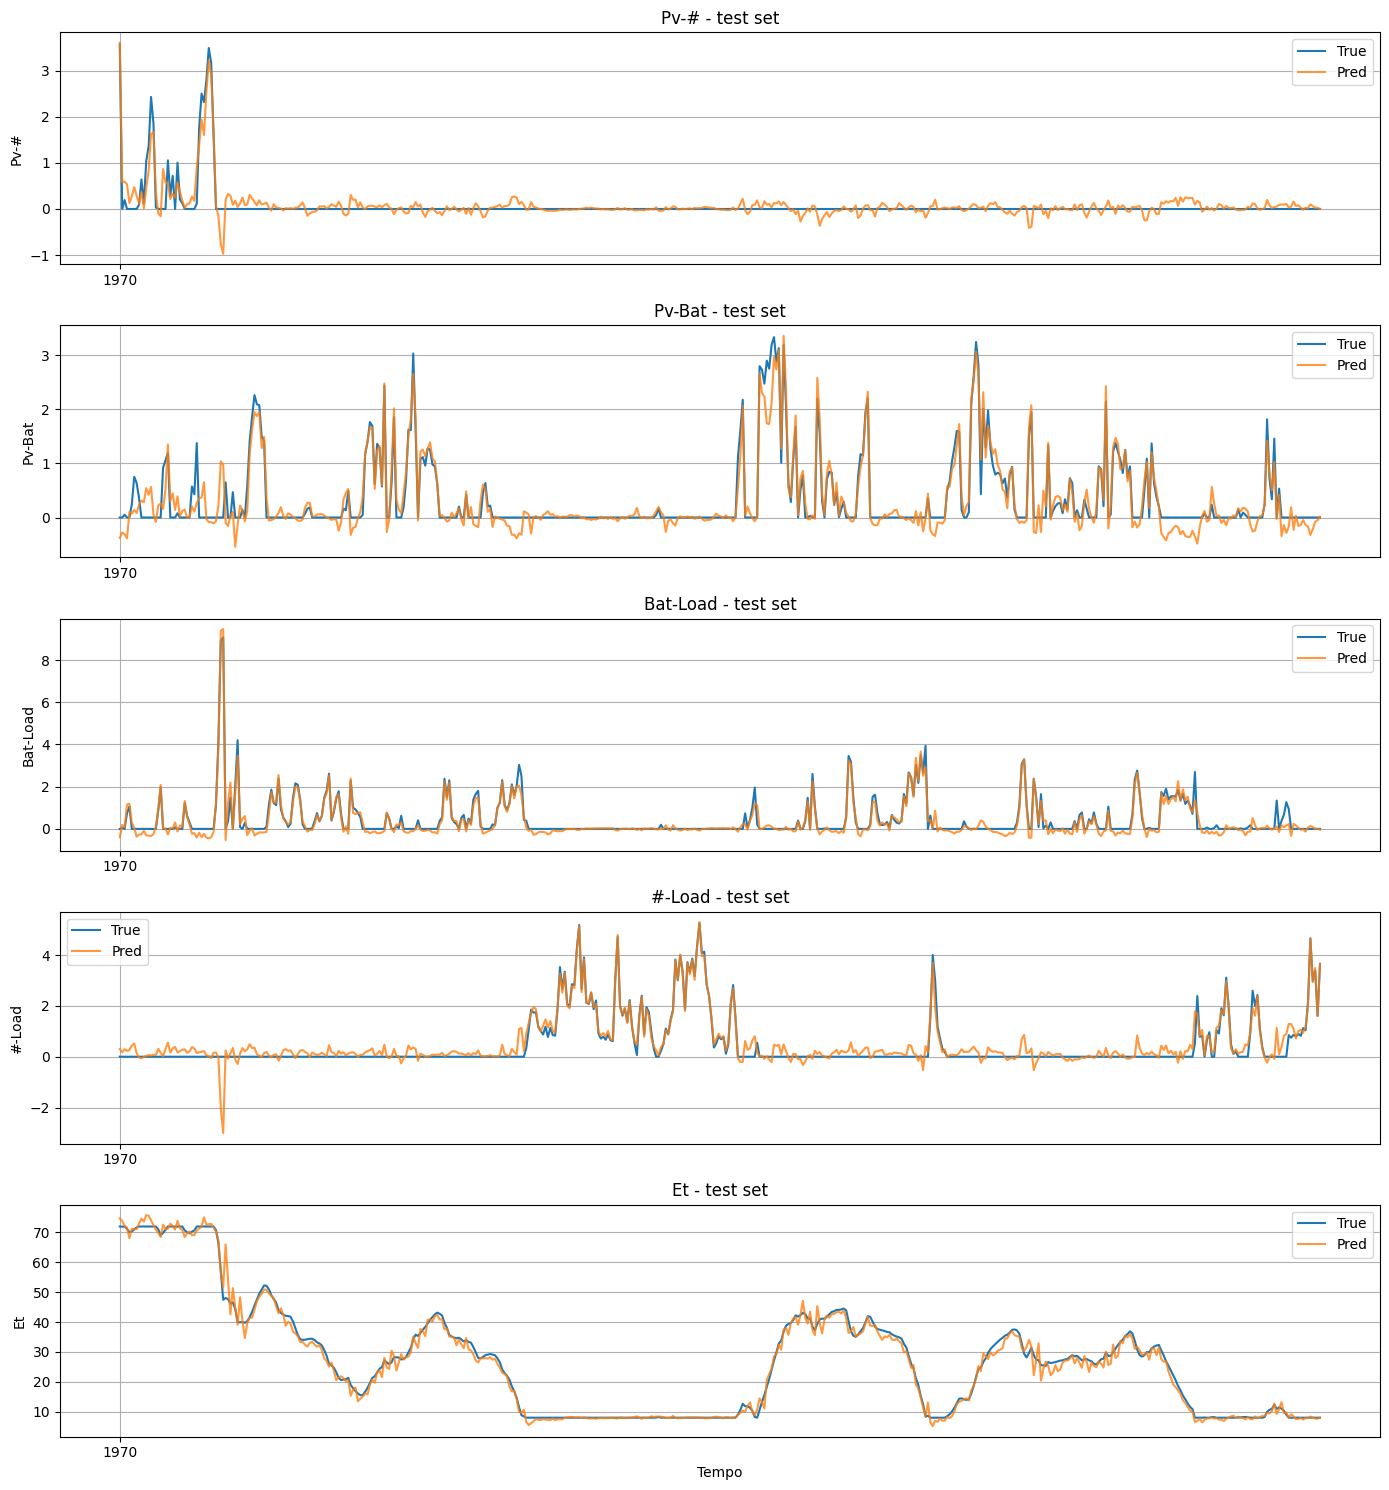

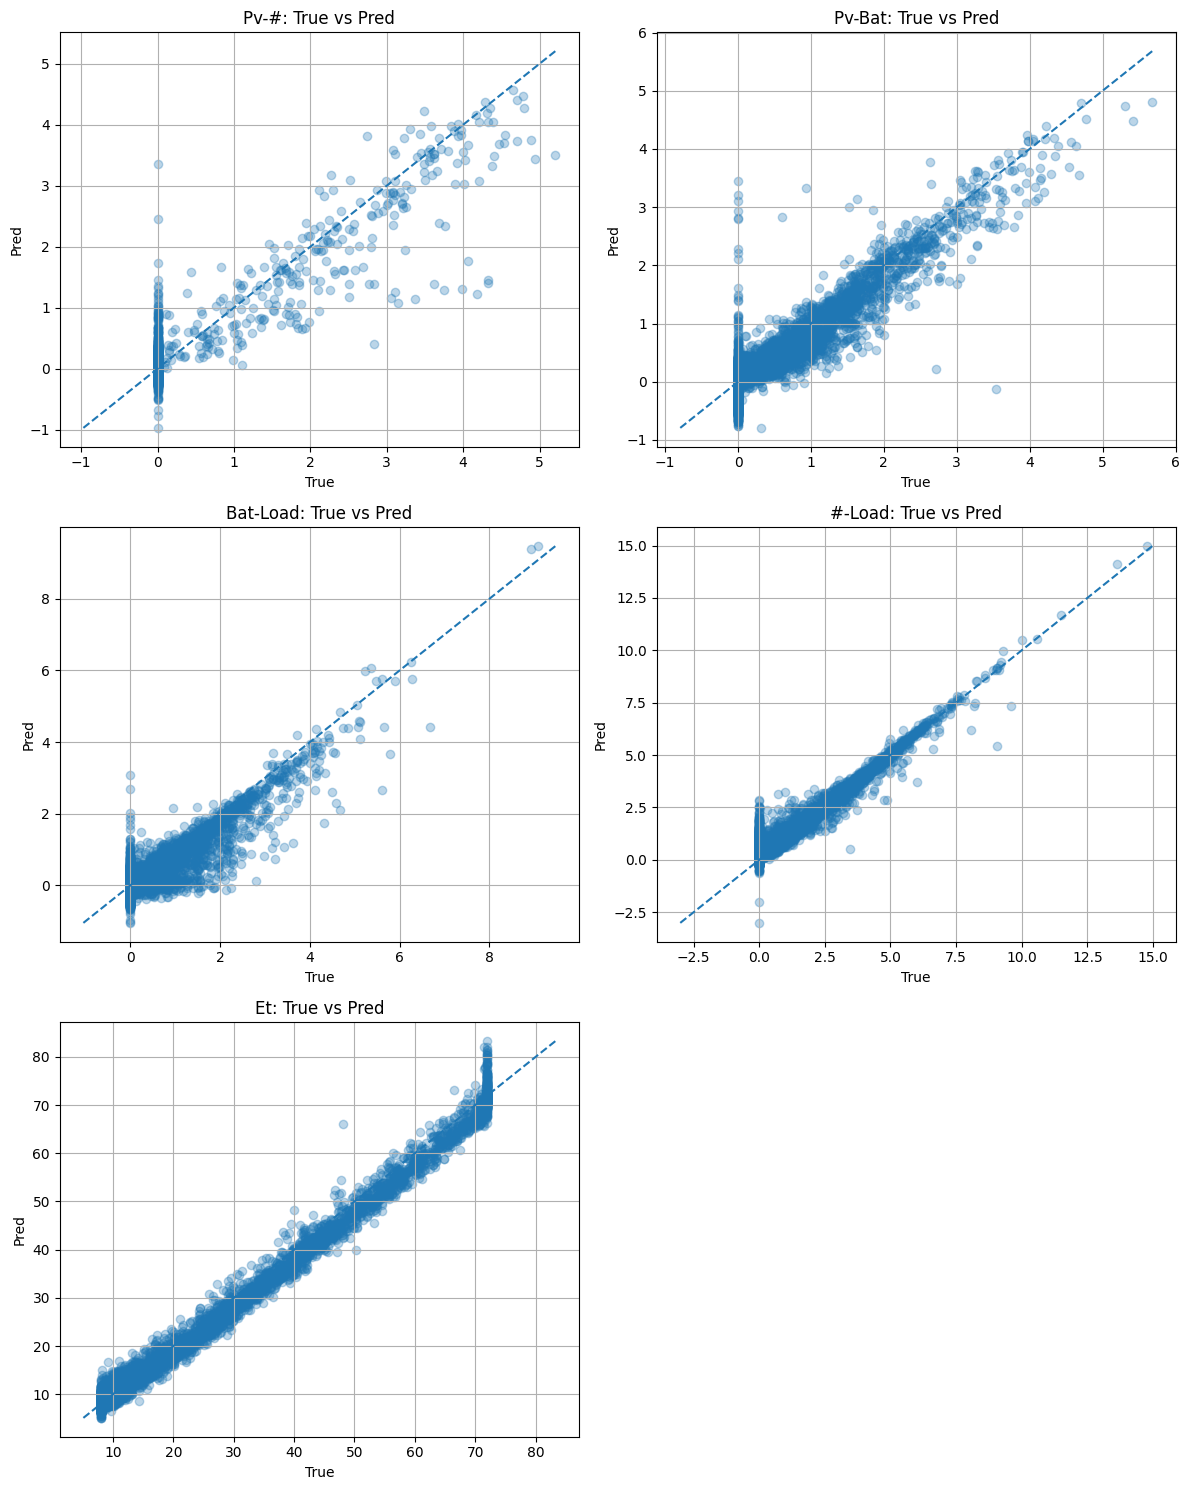

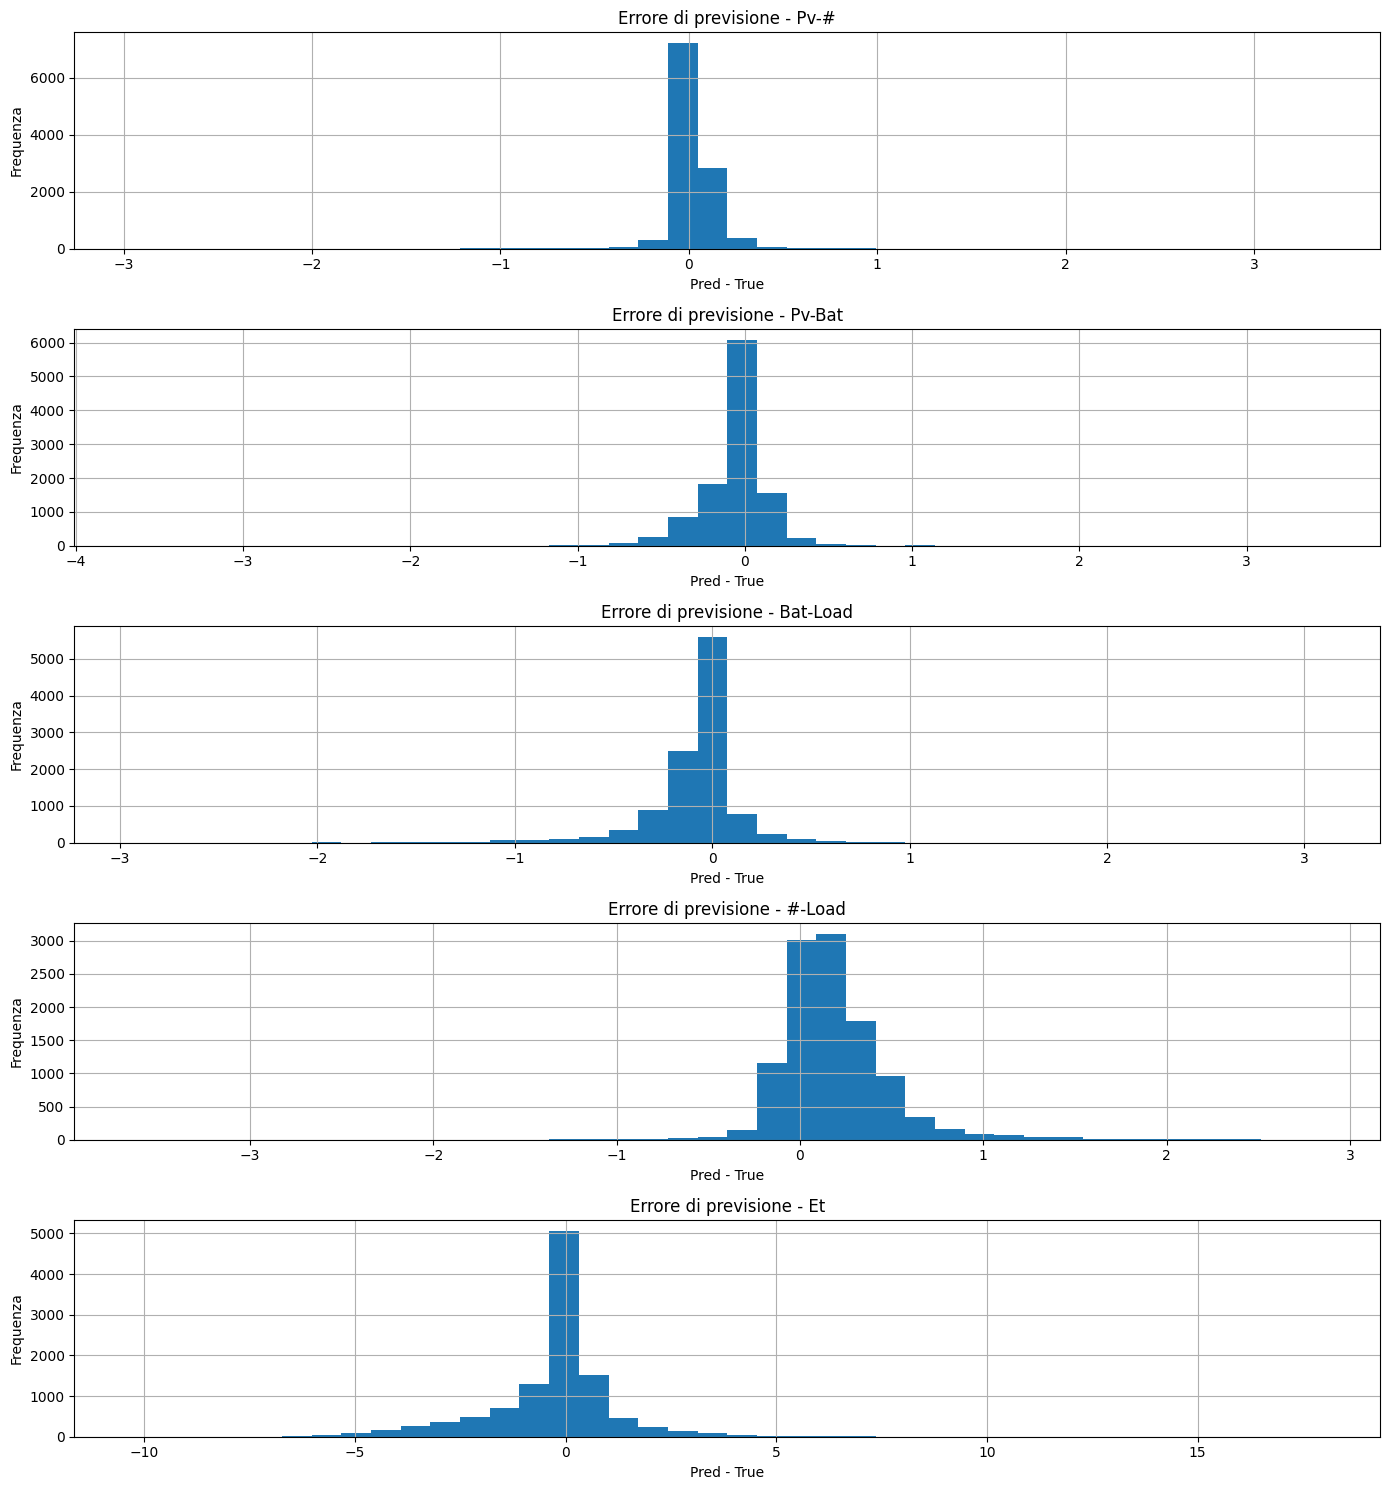

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ===========================
# 1) PREDIZIONI SUL TEST SET
# ===========================
y_test_pred = model.predict(X_test_scaled)

# Se y_test è DataFrame, lo converto in array numpy per comodità
if isinstance(y_test, pd.DataFrame):
    y_test_true = y_test.values
else:
    y_test_true = y_test

# =========================
# 2) METRICHE PER OGNI VARIABILE
# =========================
metrics_list = []

for i, col in enumerate(target_cols):
    y_true_col = y_test_true[:, i]
    y_pred_col = y_test_pred[:, i]

    mae = mean_absolute_error(y_true_col, y_pred_col)
    rmse = np.sqrt(mean_squared_error(y_true_col, y_pred_col))
    r2 = r2_score(y_true_col, y_pred_col)
   
    # Aggiungi un dizionario alla lista per ogni riga
    metrics_list.append({
        "Variabile": col,
        "MAE": f"{mae:.6f}",
        "RMSE": f"{rmse:.6f}",
        "R²": f"{r2:.6f}"
    })

# Crea il Dataframe e stampalo
df_metrics = pd.DataFrame(metrics_list)
print("\n==== Metriche sul Test Set ====")
print(df_metrics.to_string(index=False))


# =========================
# 3) DATAFRAME CONFRONTO TEST
# =========================
test_plot_df = pd.DataFrame()

# Se hai mantenuto gli indici temporali del test set, li usiamo
if isinstance(X_test, pd.DataFrame) and "DateTime" in X_test.columns:
    test_plot_df["DateTime"] = pd.to_datetime(X_test["DateTime"].values, errors="coerce")
elif "DateTime" in df.columns:
    # Se hai fatto split cronologico e vuoi recuperare il DateTime dal dataframe originale,
    # devi usare l'indice corretto del test set. Se y_test è DataFrame, possiamo riusare il suo index.
    if isinstance(y_test, pd.DataFrame):
        test_plot_df["DateTime"] = df.loc[y_test.index, "DateTime"].values
    else:
        test_plot_df["DateTime"] = np.arange(len(y_test_true))
else:
    test_plot_df["DateTime"] = np.arange(len(y_test_true))

# Aggiungo colonne vere e predette
for i, col in enumerate(target_cols):
    test_plot_df[f"{col}_true"] = y_test_true[:, i]
    test_plot_df[f"{col}_pred"] = y_test_pred[:, i]

# Ordino per DateTime se possibile
if "DateTime" in test_plot_df.columns:
    try:
        test_plot_df["DateTime"] = pd.to_datetime(test_plot_df["DateTime"], errors="coerce")
        test_plot_df = test_plot_df.sort_values("DateTime").reset_index(drop=True)
    except:
        pass

# =========================
# 4) GRAFICI TEMPORALI
# =========================
# Per leggibilità, mostriamo solo una finestra del test set
# Cambia 200 con il numero di righe che vuoi vedere
window_size = 500
plot_df = test_plot_df.iloc[:window_size].copy()

n_targets = len(target_cols)
plt.figure(figsize=(14, 3 * n_targets))

for i, col in enumerate(target_cols, 1):
    plt.subplot(n_targets, 1, i)
    plt.plot(plot_df["DateTime"], plot_df[f"{col}_true"], label="True")
    plt.plot(plot_df["DateTime"], plot_df[f"{col}_pred"], label="Pred", alpha=0.8)
    plt.title(f"{col} - test set")
    plt.ylabel(col)
    plt.grid(True)
    plt.legend()

plt.xlabel("Tempo")
plt.tight_layout()
plt.show()

# =========================
# 5) SCATTER TRUE VS PRED
# =========================
fig, axes = plt.subplots((n_targets + 1) // 2, 2, figsize=(12, 5 * ((n_targets + 1) // 2)))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(target_cols):
    y_true_col = test_plot_df[f"{col}_true"].values
    y_pred_col = test_plot_df[f"{col}_pred"].values

    axes[i].scatter(y_true_col, y_pred_col, alpha=0.3)
    mn = min(y_true_col.min(), y_pred_col.min())
    mx = max(y_true_col.max(), y_pred_col.max())
    axes[i].plot([mn, mx], [mn, mx], linestyle="--")
    axes[i].set_title(f"{col}: True vs Pred")
    axes[i].set_xlabel("True")
    axes[i].set_ylabel("Pred")
    axes[i].grid(True)

# Rimuovo assi vuoti se i target sono dispari
for j in range(len(target_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# =========================
# 6) ISTOGRAMMI DEGLI ERRORI
# =========================
plt.figure(figsize=(14, 3 * n_targets))

for i, col in enumerate(target_cols, 1):
    error = test_plot_df[f"{col}_pred"] - test_plot_df[f"{col}_true"]
    plt.subplot(n_targets, 1, i)
    plt.hist(error, bins=40)
    plt.title(f"Errore di previsione - {col}")
    plt.xlabel("Pred - True")
    plt.ylabel("Frequenza")
    plt.grid(True)

plt.tight_layout()
plt.show()